In [1]:
import pandas as pd

# Load the dataset
file_path = '/content/Carbon FootPrint - Regression .csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Personal_Vehicle_Km,Public_Vehicle_Km,Plane_Journey_Count,Train_Journey_Count,Electricity_Kwh,Water_Usage_Liters,Diet_Type,Waste_Kg,Carbon_Footprint_Kg
0,49.771537,67.597204,4,9,299.578448,51.799940,Veg,0.433914,52.475928
1,64.476199,-49.000833,1,0,16.145718,-170.486021,MostlyVeg,0.447913,12.503403
2,-47.753889,2.133305,9,1,187.377441,-159.132762,NonVeg,0.397881,33.154768
3,1.572282,-47.871388,1,2,366.394573,-141.009555,Veg,0.451903,7.213233
4,28.137154,2.442315,1,10,455.301692,-129.647609,Both,0.357465,28.894928


### Initial Data Inspection
Let's check the DataFrame's information to understand data types and non-null values, and then view descriptive statistics.

In [2]:
# Get a concise summary of the DataFrame
df.info()

# Display descriptive statistics
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Personal_Vehicle_Km  1000 non-null   float64
 1   Public_Vehicle_Km    1000 non-null   float64
 2   Plane_Journey_Count  1000 non-null   int64  
 3   Train_Journey_Count  1000 non-null   int64  
 4   Electricity_Kwh      1000 non-null   float64
 5   Water_Usage_Liters   1000 non-null   float64
 6   Diet_Type            1000 non-null   object 
 7   Waste_Kg             1000 non-null   float64
 8   Carbon_Footprint_Kg  1000 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 70.4+ KB


,Personal_Vehicle_Km,Public_Vehicle_Km,Plane_Journey_Count,Train_Journey_Count,Electricity_Kwh,Water_Usage_Liters,Waste_Kg,Carbon_Footprint_Kg
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-2.464295,3.006082,4.882000,5.022000,109.261958,23.344705,0.420020,30.018255
std,40.444425,39.838132,3.114768,3.212762,202.333161,134.594164,0.044556,17.371370
min,-146.062158,-133.054767,0.000000,0.000000,-448.167960,-362.030549,0.340025,-23.077035
25%,-27.852235,-25.581678,2.000000,2.000000,-31.072811,-67.054496,0.384435,17.759713
50%,-4.315215,1.345928,5.000000,5.000000,113.189762,25.270250,0.419589,29.636267
75%,23.781986,31.846858,8.000000,8.000000,244.284437,114.165091,0.457873,42.681845
max,109.019529,122.594561,10.000000,10.000000,763.097466,475.447979,0.499934,81.415361


### Data Cleaning: Handling Illogical Negative Values
As observed in the descriptive statistics, several columns (`Personal_Vehicle_Km`, `Public_Vehicle_Km`, `Electricity_Kwh`, `Water_Usage_Liters`, `Carbon_Footprint_Kg`) contain negative values, which are physically impossible. I will replace these negative values with zero to ensure data integrity.

In [3]:
# List of columns to clean
columns_to_clean = [
    'Personal_Vehicle_Km',
    'Public_Vehicle_Km',
    'Electricity_Kwh',
    'Water_Usage_Liters',
    'Carbon_Footprint_Kg'
]

# Replace negative values with 0 in the specified columns
for col in columns_to_clean:
    df[col] = df[col].apply(lambda x: max(x, 0))

# Display descriptive statistics again to verify the changes
display(df[columns_to_clean].describe())

,Personal_Vehicle_Km,Public_Vehicle_Km,Electricity_Kwh,Water_Usage_Liters,Carbon_Footprint_Kg
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,14.930225,17.744458,146.689424,66.232224,30.260661
std,23.414851,24.119077,153.467419,86.689558,16.870710
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,17.759713
50%,0.000000,1.345928,113.189762,25.270250,29.636267
75%,23.781986,31.846858,244.284437,114.165091,42.681845
max,109.019529,122.594561,763.097466,475.447979,81.415361


### Exploratory Data Analysis (EDA): Visualizations
Now that the data has been cleaned, let's perform some exploratory data analysis to understand the distributions of features and their relationships, especially with the target variable `Carbon_Footprint_Kg`.

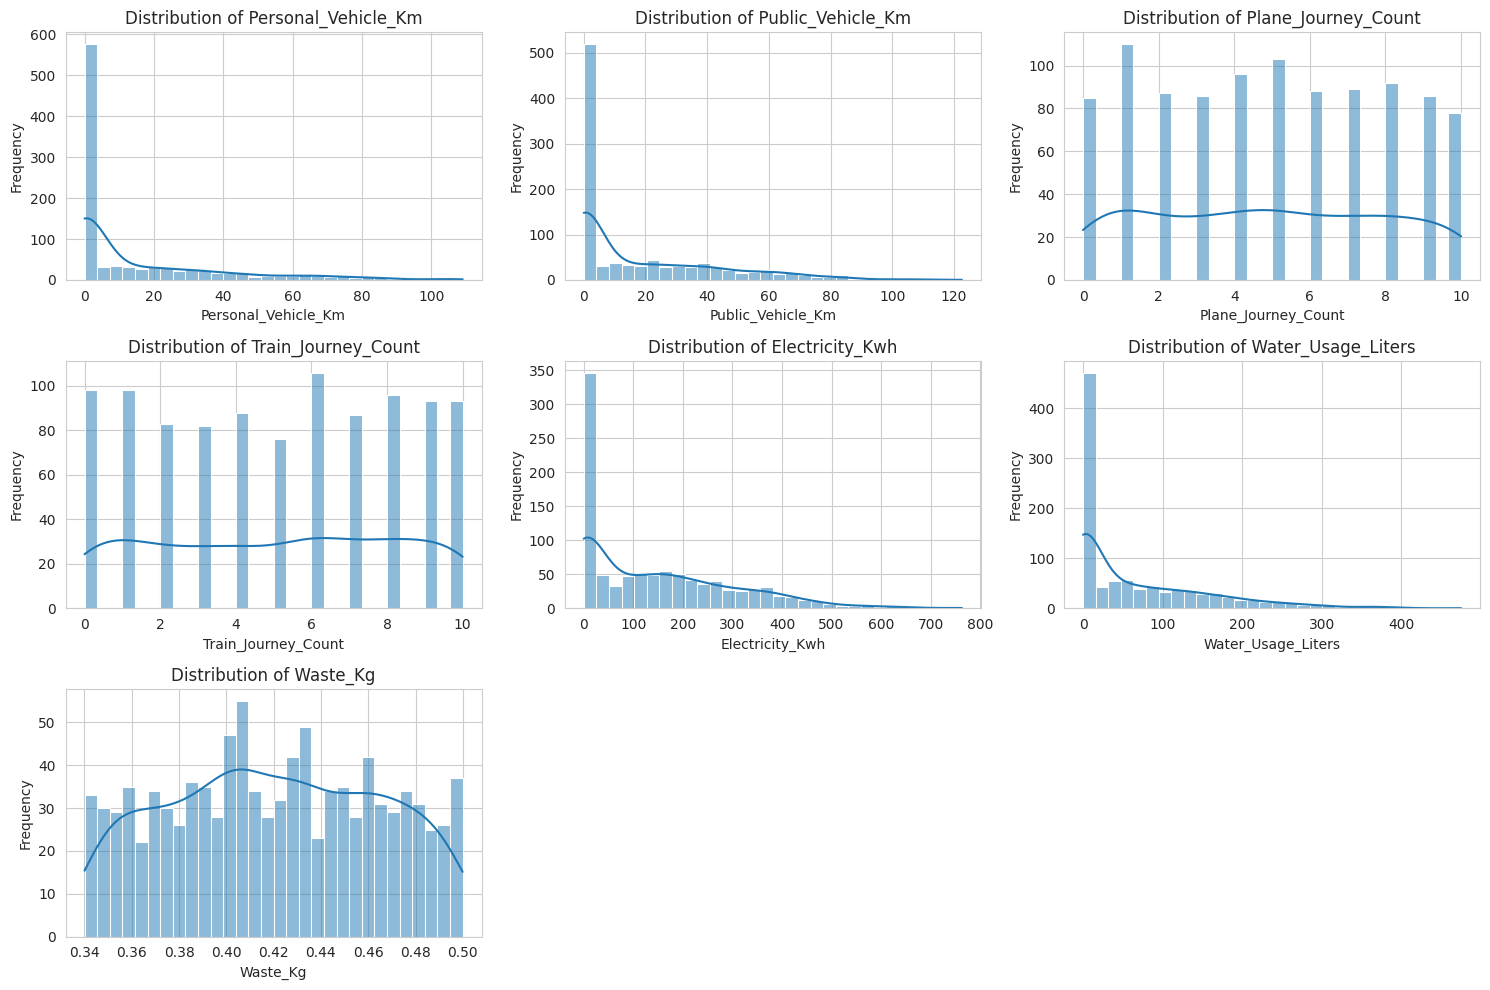

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Get numerical columns (excluding the target for now, to plot separately)
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Drop Carbon_Footprint_Kg from this list to plot its distribution separately later if needed
if 'Carbon_Footprint_Kg' in numerical_cols:
    numerical_cols.remove('Carbon_Footprint_Kg')

# Create histograms for all numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i) # Adjust subplot grid size as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Correlation Analysis
Let's visualize the correlation matrix to understand the linear relationships between all numerical features, including our target variable `Carbon_Footprint_Kg`.

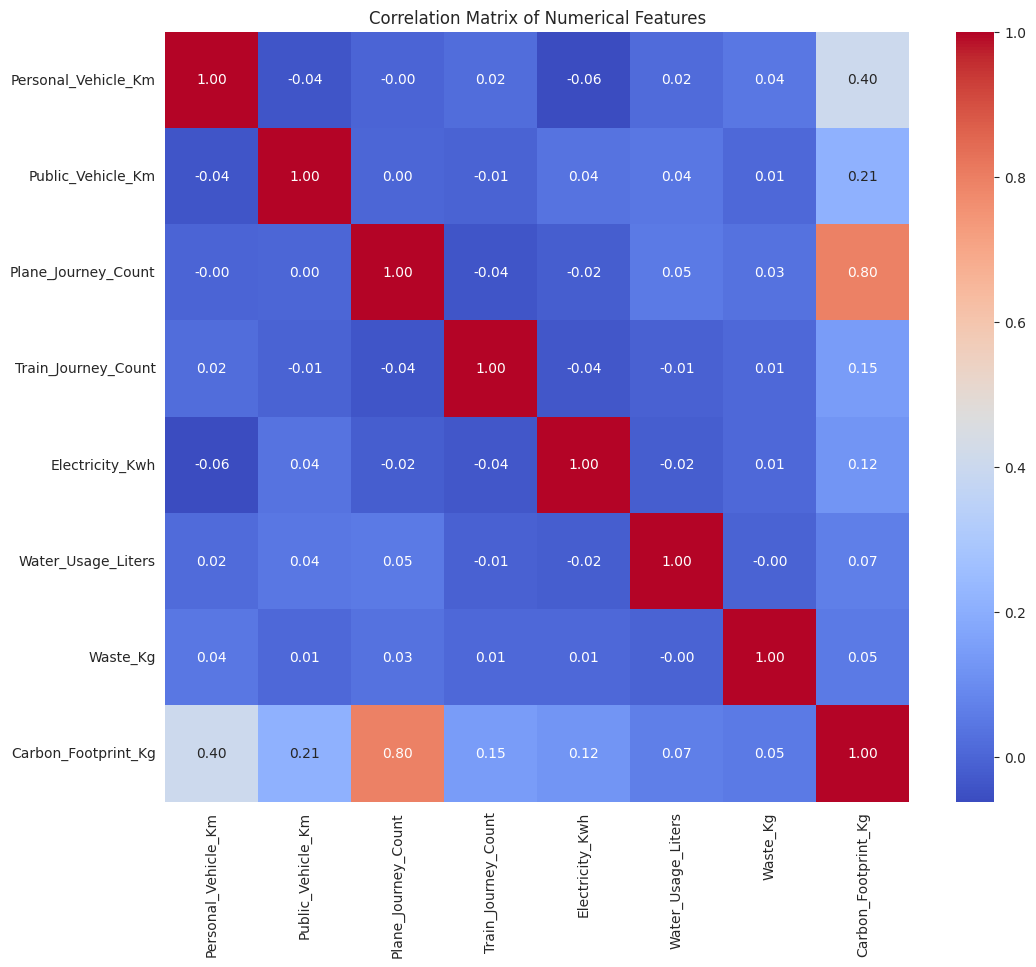

In [5]:
# Calculate the correlation matrix
correlation_matrix = df.select_dtypes(include=['float64', 'int64']).corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Relationship with Target Variable (`Carbon_Footprint_Kg`)
Now, let's look at scatter plots to directly observe the relationship of each numerical feature with `Carbon_Footprint_Kg`.

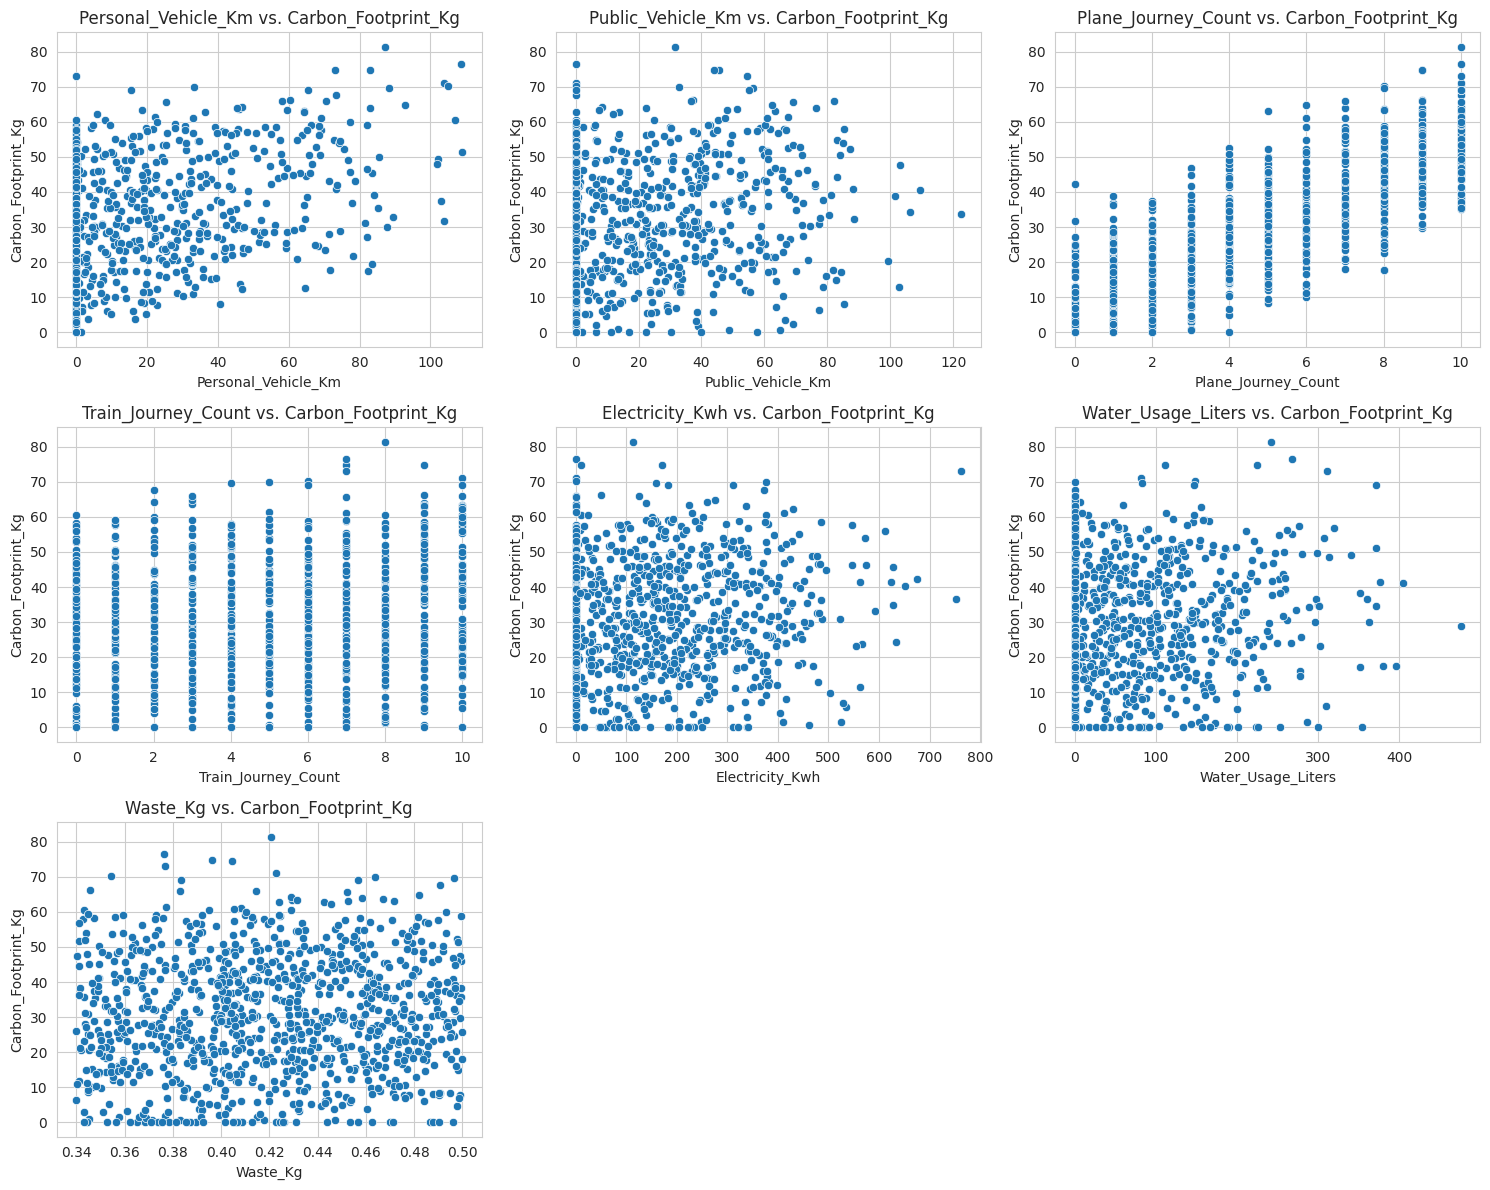

In [6]:
# Create scatter plots of numerical features vs. Carbon_Footprint_Kg
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i) # Adjust subplot grid size as needed
    sns.scatterplot(x=df[col], y=df['Carbon_Footprint_Kg'])
    plt.title(f'{col} vs. Carbon_Footprint_Kg')
    plt.xlabel(col)
    plt.ylabel('Carbon_Footprint_Kg')
plt.tight_layout()
plt.show()

### Analyze Categorical Feature: `Diet_Type`
Finally, let's explore how the categorical feature `Diet_Type` relates to `Carbon_Footprint_Kg`.

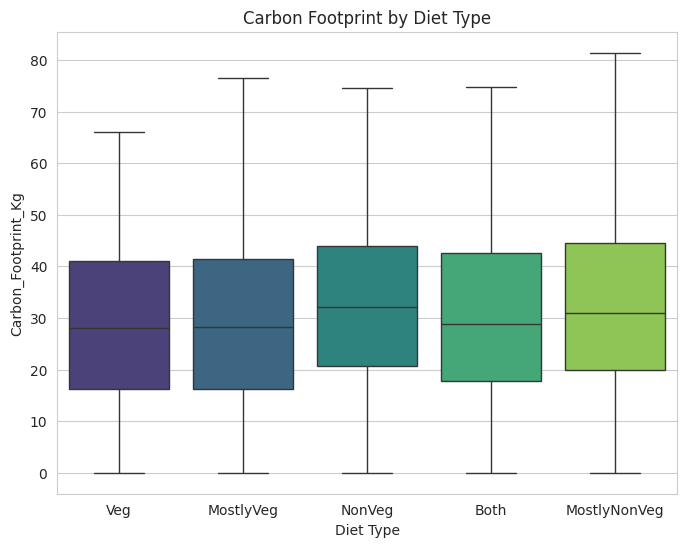

In [8]:
# Analyze 'Diet_Type' against 'Carbon_Footprint_Kg'
plt.figure(figsize=(8, 6))
sns.boxplot(x='Diet_Type', y='Carbon_Footprint_Kg', data=df, palette='viridis', hue='Diet_Type', legend=False)
plt.title('Carbon Footprint by Diet Type')
plt.xlabel('Diet Type')
plt.ylabel('Carbon_Footprint_Kg')
plt.show()

### Feature Engineering: Handling Categorical Variables
Now, let's encode the categorical `Diet_Type` column using one-hot encoding to prepare it for machine learning models.

In [9]:
# Apply one-hot encoding to 'Diet_Type'
df = pd.get_dummies(df, columns=['Diet_Type'], drop_first=True)

# Display the first few rows of the DataFrame with the new encoded columns
display(df.head())

,Personal_Vehicle_Km,Public_Vehicle_Km,Plane_Journey_Count,Train_Journey_Count,Electricity_Kwh,Water_Usage_Liters,Waste_Kg,Carbon_Footprint_Kg,Diet_Type_MostlyNonVeg,Diet_Type_MostlyVeg,Diet_Type_NonVeg,Diet_Type_Veg
0,49.771537,67.597204,4,9,299.578448,51.79994,0.433914,52.475928,False,False,False,True
1,64.476199,0.000000,1,0,16.145718,0.00000,0.447913,12.503403,False,True,False,False
2,0.000000,2.133305,9,1,187.377441,0.00000,0.397881,33.154768,False,False,True,False
3,1.572282,0.000000,1,2,366.394573,0.00000,0.451903,7.213233,False,False,False,True
4,28.137154,2.442315,1,10,455.301692,0.00000,0.357465,28.894928,False,False,False,False


### Model Building: Random Forest Regressor
Now, let's prepare the data for machine learning and build a Random Forest Regressor model to predict `Carbon_Footprint_Kg`.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop('Carbon_Footprint_Kg', axis=1)
y = df['Carbon_Footprint_Kg']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (800, 11)
Testing set shape: (200, 11)


In [11]:
# Initialize the Random Forest Regressor model
# You can tune hyperparameters like n_estimators, max_depth, etc.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


### Model Evaluation
Let's evaluate the performance of the Random Forest Regressor on the test set using key regression metrics.

In [13]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf**0.5  # Calculate RMSE by taking the square root of MSE
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"  R-squared (R2): {r2_rf:.4f}")

Random Forest Regressor Performance:
  Mean Absolute Error (MAE): 4.9932
  Mean Squared Error (MSE): 37.3353
  Root Mean Squared Error (RMSE): 6.1103
  R-squared (R2): 0.8724


### Model Performance Summary

In [14]:
model_performance = pd.DataFrame({
    'Metric': ['Mean Absolute Error (MAE)', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 'R-squared (R2)'],
    'Random Forest Regressor': [mae_rf, mse_rf, rmse_rf, r2_rf]
})

display(model_performance)

,Metric,Random Forest Regressor
0,Mean Absolute Error (MAE),4.993232
1,Mean Squared Error (MSE),37.335255
2,Root Mean Squared Error (RMSE),6.110258
3,R-squared (R2),0.872410


### Hyperparameter Tuning with GridSearchCV
Let's use GridSearchCV to find the optimal hyperparameters for our Random Forest Regressor. This will help us potentially improve the model's accuracy.

In [16]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2'],  # Number of features to consider when looking for the best split
    'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]  # Minimum number of samples required to be at a leaf node
}

# Initialize a new Random Forest Regressor instance
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("GridSearchCV completed successfully!")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
GridSearchCV completed successfully!


In [17]:
# Print the best parameters and the best score
print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best negative MSE score: {grid_search.best_score_}")

# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_best_rf = best_rf_model.predict(X_test)

# Evaluate the best model
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = mse_best_rf**0.5
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print(f"\nRandom Forest Regressor Performance with Best Parameters:")
print(f"  Mean Absolute Error (MAE): {mae_best_rf:.4f}")
print(f"  Mean Squared Error (MSE): {mse_best_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_best_rf:.4f}")
print(f"  R-squared (R2): {r2_best_rf:.4f}")

Best parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best negative MSE score: -46.2713689731691

Random Forest Regressor Performance with Best Parameters:
  Mean Absolute Error (MAE): 5.1506
  Mean Squared Error (MSE): 40.6821
  Root Mean Squared Error (RMSE): 6.3783
  R-squared (R2): 0.8610


### Comparison of Model Performance (Before and After Tuning)

In [18]:
# Update the model_performance DataFrame with the tuned model's metrics
model_performance['Tuned Random Forest Regressor'] = [
    mae_best_rf, mse_best_rf, rmse_best_rf, r2_best_rf
]

display(model_performance)

,Metric,Random Forest Regressor,Tuned Random Forest Regressor
0,Mean Absolute Error (MAE),4.993232,5.150626
1,Mean Squared Error (MSE),37.335255,40.682091
2,Root Mean Squared Error (RMSE),6.110258,6.378251
3,R-squared (R2),0.872410,0.860973


### Model Building: XGBoost Regressor
Let's train an XGBoost Regressor model and evaluate its performance to compare with the Random Forest models.

In [19]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features (X) and target (y) if not already defined (re-run for clarity)
X = df.drop('Carbon_Footprint_Kg', axis=1)
y = df['Carbon_Footprint_Kg']

# Split the data into training and testing sets (use the same split as before for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost Regressor model trained successfully!")

XGBoost Regressor model trained successfully!


### XGBoost Model Evaluation

In [20]:
# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = mse_xgb**0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"  Mean Squared Error (MSE): {mse_xgb:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"  R-squared (R2): {r2_xgb:.4f}")

XGBoost Regressor Performance:
  Mean Absolute Error (MAE): 4.8280
  Mean Squared Error (MSE): 35.2140
  Root Mean Squared Error (RMSE): 5.9341
  R-squared (R2): 0.8797


### Comparison of All Model Performances

In [21]:
# Update the model_performance DataFrame with XGBoost metrics
model_performance['XGBoost Regressor'] = [
    mae_xgb, mse_xgb, rmse_xgb, r2_xgb
]

display(model_performance)

,Metric,Random Forest Regressor,Tuned Random Forest Regressor,XGBoost Regressor
0,Mean Absolute Error (MAE),4.993232,5.150626,4.827970
1,Mean Squared Error (MSE),37.335255,40.682091,35.214043
2,Root Mean Squared Error (RMSE),6.110258,6.378251,5.934142
3,R-squared (R2),0.872410,0.860973,0.879659


### Visual Comparison of Model Performances
Let's visualize the performance metrics of all three models to get a clear comparative view.

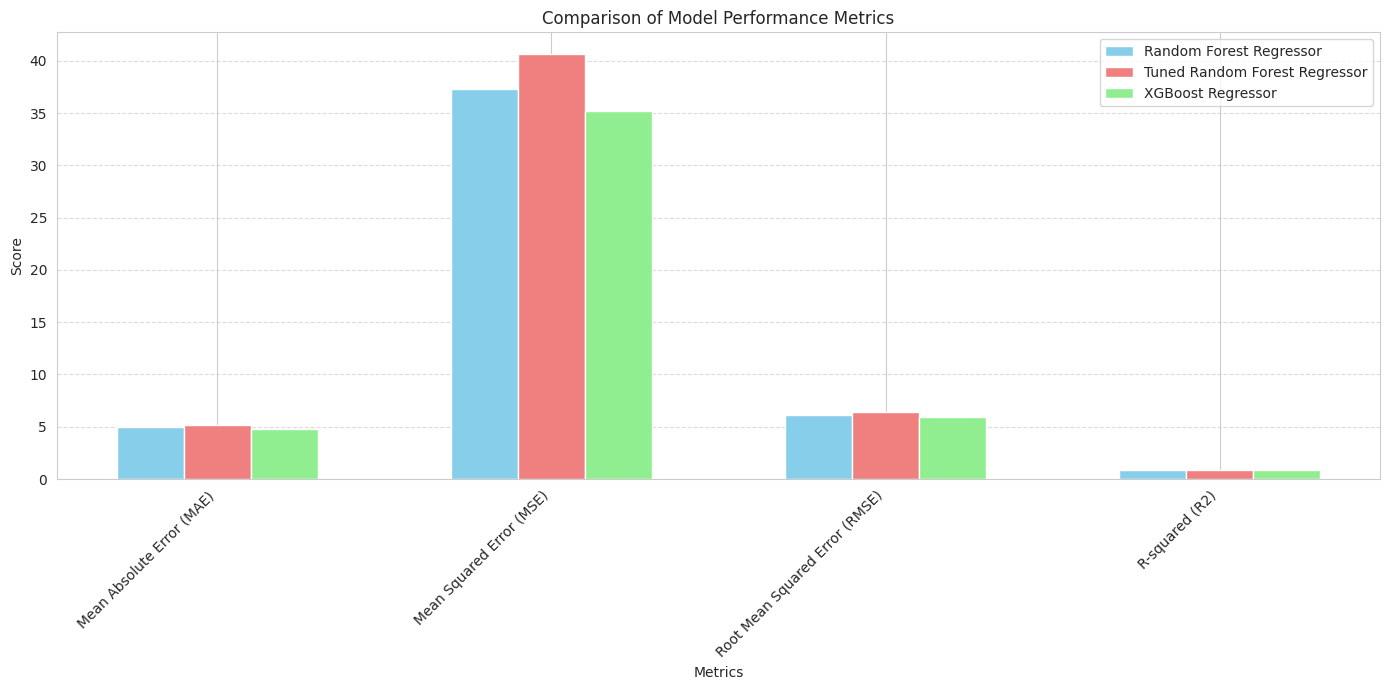

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

# Prepare data for plotting
metrics = model_performance['Metric'].tolist()
rf_scores = model_performance['Random Forest Regressor'].tolist()
tuned_rf_scores = model_performance['Tuned Random Forest Regressor'].tolist()
xgb_scores = model_performance['XGBoost Regressor'].tolist()

num_metrics = len(metrics)
ind = np.arange(num_metrics)  # the x locations for the groups
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(14, 7))

# Plotting bars for each model
rects1 = ax.bar(ind - width, rf_scores, width, label='Random Forest Regressor', color='skyblue')
rects2 = ax.bar(ind, tuned_rf_scores, width, label='Tuned Random Forest Regressor', color='lightcoral')
rects3 = ax.bar(ind + width, xgb_scores, width, label='XGBoost Regressor', color='lightgreen')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Comparison of Model Performance Metrics')
ax.set_xticks(ind)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Final Model Selection and Saving
Based on the comparative analysis, the **XGBoost Regressor** generally exhibits the best performance with the lowest MAE, MSE, RMSE, and the highest R-squared value.

Therefore, we will select the XGBoost Regressor as our final model. We will now save this model for future use.

In [23]:
import joblib

# Select the best model (XGBoost Regressor in this case)
best_model = xgb_model # Assuming xgb_model is the trained XGBoost model from previous steps

# Define the filename for saving the model
model_filename = 'best_carbon_footprint_model.joblib'

# Save the model to disk
joblib.dump(best_model, model_filename)

print(f"Best model (XGBoost Regressor) saved as {model_filename}")

Best model (XGBoost Regressor) saved as best_carbon_footprint_model.joblib
